<a href="https://colab.research.google.com/github/crahulnaidu/recursive-self-improving-ai/blob/main/month_1/ai_month_1_day_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Comparing the convergence rate of a simple linear regression model with a constant learing rate and a exponentail learning rate

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
np.random.seed(42)

X=np.random.rand(100,1)
y=5*X+np.random.randn(100,1)*0.1

def train(learning_rate_type='constant'):
  w=0.0
  loss_history=[]
  lr=0.5

  for epoch in range(50):
    #Forward pass and loss(MSE)
    prediction=X*w
    loss=np.mean((prediction-y)**2)
    loss_history.append(loss)

    gradient=-2*np.mean(X*(y-prediction))

    #Learning rate scheduling

    if learning_rate_type=='adjustable':
      current_lr=lr*(0.9**epoch)

    else:
      current_lr=lr

    w-=current_lr*gradient

  return loss_history





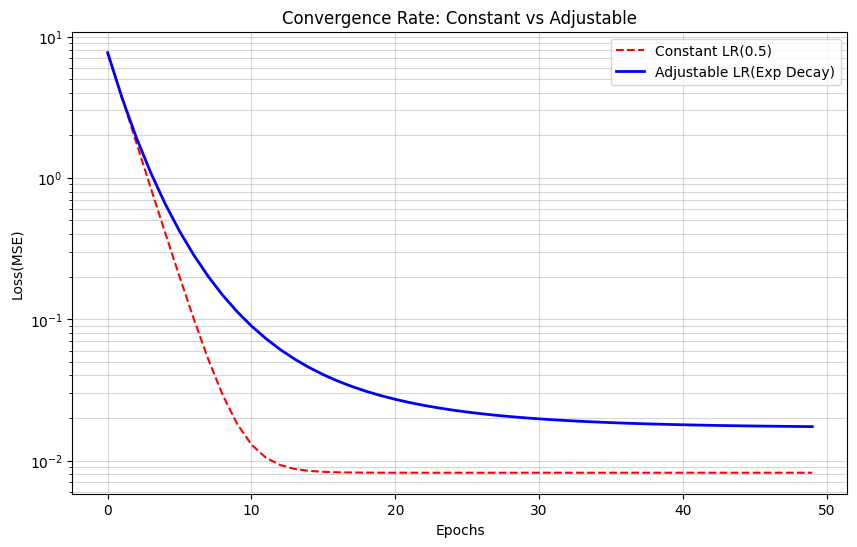

In [7]:
loss_constant=train('constant')
loss_adjustable=train('adjustable')

plt.figure(figsize=(10,6))
plt.plot(loss_constant,label='Constant LR(0.5)',color='red',linestyle='--')
plt.plot(loss_adjustable,label='Adjustable LR(Exp Decay)',color='blue',linewidth=2)
plt.yscale('log')
plt.xlabel("Epochs")
plt.ylabel("Loss(MSE)")
plt.title("Convergence Rate: Constant vs Adjustable")
plt.legend()
plt.grid(True,which='both',ls='-',alpha=0.5)
plt.show()